# Fermi Weekly Analysis

这个 notebook 用于 Mrk 421 的 Fermi weekly light curve 分析，并裁剪到与 WCDA 相同的观测时间范围。
当前只看真实数据上的 light curve、Morlet CWT 和 WWZ，不做模拟光变、Monte Carlo 或显著性检验。

旧版 notebook 已归档到 `notebooks/archive/`，这里保留的是更适合顺着阅读的共同时段分析版本。

## 1. 导入依赖与路径定位

In [1]:
from pathlib import Path
import ast

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pycwt as wavelet
from scipy.signal import find_peaks
from libwwz import wwt


def locate_project_root(markers=("data", "notebooks", "src")):
    # 从当前工作目录向上回溯，找到仓库根目录。
    # 这样 notebook 不依赖你是从哪里启动的。
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if all((candidate / marker).exists() for marker in markers):
            return candidate
    raise FileNotFoundError(f"Could not locate project root from {cwd}")


PROJECT_ROOT = locate_project_root()
DATA_ROOT = PROJECT_ROOT / "data"
NOTEBOOK_ROOT = PROJECT_ROOT / "notebooks"

plt.rcParams.update({
    "figure.figsize": (10, 4),
    "axes.grid": True,
    "grid.alpha": 0.3,
    "axes.titlesize": 15,
    "axes.labelsize": 13,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = /mnt/mydisk/server/projects/QPO


## 2. 数据加载

读取已经做过 TS 筛选的 Fermi weekly CSV，再把 WCDA 的时间范围作为裁剪边界。

In [2]:
fermi_candidates = [
    DATA_ROOT / 'processed' / 'fermi_week' / 'Mrk421_Fermi_weekly_TSge9_MJD.csv',
    *sorted((DATA_ROOT / 'processed' / 'fermi_week').glob('*.csv')),
]
FERMI_WEEKLY_CSV = next((path for path in fermi_candidates if path.exists()), None)
if FERMI_WEEKLY_CSV is None:
    raise FileNotFoundError('Could not locate the processed Fermi weekly CSV under data/processed/fermi_week/.')

WCDA_CSV = DATA_ROOT / 'raw' / 'wcda' / 'LHAASO-WCDA_Mrk421_2021-03-08_2025-11-06_week(1).csv'
if not WCDA_CSV.exists():
    raise FileNotFoundError(f'Missing WCDA CSV: {WCDA_CSV}')

# Fermi CSV 已经是 `mjd, flux, flux_err` 格式，读入后直接用于后续筛选。
df_fermi_raw = pd.read_csv(FERMI_WEEKLY_CSV)
df_wcda_raw = pd.read_csv(WCDA_CSV, comment='#')
df_wcda_raw.columns = [col.strip() for col in df_wcda_raw.columns]

print('FERMI_WEEKLY_CSV =', FERMI_WEEKLY_CSV)
print('rows =', len(df_fermi_raw))
print('columns =', list(df_fermi_raw.columns))
print('raw MJD range =', float(df_fermi_raw['mjd'].min()), '->', float(df_fermi_raw['mjd'].max()))
df_fermi_raw.head()

FERMI_WEEKLY_CSV = /mnt/mydisk/server/projects/QPO/data/processed/fermi_week/Mrk421_Fermi_weekly_TSge9_MJD.csv
rows = 892
columns = ['mjd', 'flux', 'flux_err']
raw MJD range = 54687.49998842592 -> 61062.49994212963


,mjd,flux,flux_err
0,54687.499988,1.180988e-07,4.289548e-08
1,54694.499988,1.526203e-07,4.156840e-08
2,54701.499988,2.043436e-07,4.162709e-08
3,54708.499988,1.797099e-07,3.007431e-08
4,54715.499988,1.970055e-07,3.559737e-08


## 3. 时间裁剪与数据预处理

保留与 WCDA 完全重叠的时间段，并按时间排序，保证后续 CWT / WWZ 输入稳定。

In [3]:
wcda_t_start = float(df_wcda_raw['mjd'].min())
wcda_t_end = float(df_wcda_raw['mjd'].max())

df_fermi = df_fermi_raw.copy()
before_count = len(df_fermi)
# 先做基础质量控制，再裁剪到和 WCDA 一样的时间窗口。
valid_mask = (
    np.isfinite(df_fermi['mjd'])
    & np.isfinite(df_fermi['flux'])
    & np.isfinite(df_fermi['flux_err'])
    & (df_fermi['flux_err'] > 0)
)
overlap_mask = (df_fermi['mjd'] >= wcda_t_start) & (df_fermi['mjd'] <= wcda_t_end)
df_fermi = df_fermi.loc[valid_mask & overlap_mask].copy()
df_fermi = df_fermi.sort_values('mjd').reset_index(drop=True)

t_fermi = df_fermi['mjd'].to_numpy(dtype=float)
flux_fermi = df_fermi['flux'].to_numpy(dtype=float)
flux_err_fermi = df_fermi['flux_err'].to_numpy(dtype=float)

print('WCDA overlap range =', wcda_t_start, '->', wcda_t_end)
print('points before cut =', before_count)
print('points after cut  =', len(df_fermi))
print('final MJD range   =', float(t_fermi.min()), '->', float(t_fermi.max()))
print('median cadence [day] =', float(np.median(np.diff(t_fermi))))
df_fermi.head()

WCDA overlap range = 59284.33328206009 -> 60983.58347916683
points before cut = 892
points after cut  = 238
final MJD range   = 59284.49994212963 -> 60978.49994212963
median cadence [day] = 7.0


,mjd,flux,flux_err
0,59284.499942,1.357349e-07,3.816474e-08
1,59291.499942,8.416250e-08,2.486591e-08
2,59298.499942,2.371618e-07,3.779052e-08
3,59305.499942,2.516651e-07,3.195481e-08
4,59312.499942,2.269661e-07,3.556756e-08


## 4. 光变可视化

先看裁剪后的 Fermi weekly 光变，确认时间段和误差条是否正常。

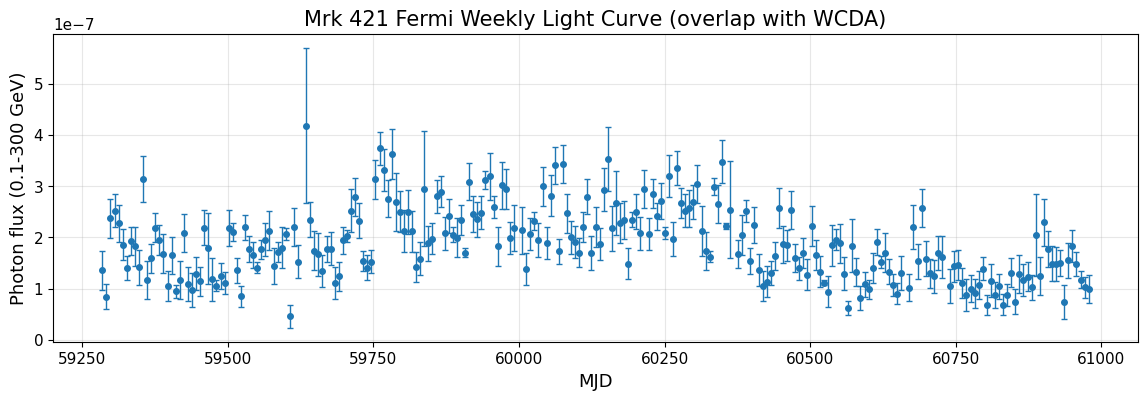

In [4]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.errorbar(
    t_fermi,
    flux_fermi,
    yerr=flux_err_fermi,
    fmt='o',
    ms=4,
    capsize=2,
    elinewidth=1,
)
ax.set_xlabel('MJD')
ax.set_ylabel('Photon flux (0.1-300 GeV)')
ax.set_title('Mrk 421 Fermi Weekly Light Curve (overlap with WCDA)')
plt.show()

## 5. CWT 分析

和 WCDA 保持同一套 Morlet 参数，方便直接横向比较周期结构。

In [5]:

# 小波变换前先做标准化，避免均值和量纲影响 power 的比较。
def standardize_flux(flux):
    flux = np.asarray(flux, dtype=float)
    flux = flux - np.nanmean(flux)
    std = np.nanstd(flux)
    if not np.isfinite(std) or std == 0:
        raise ValueError("Flux standard deviation is zero or non-finite.")
    return flux / std



# 统一封装 CWT，方便 WCDA / Fermi 两本 notebook 使用同一套参数。
def run_cwt(t_mjd, flux, *, dj=1/12, period_min=50.0, period_max=600.0, mother=None):
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    dt = float(np.median(np.diff(t_mjd)))
    if mother is None:
        mother = wavelet.Morlet(6)
    s0 = 2.0 * dt
    J = int(np.log2(len(flux) * dt / s0) / dj)

    y = standardize_flux(flux)
    wave, scales, freqs, coi, fft, fftfreqs = wavelet.cwt(
        y,
        dt,
        dj=dj,
        s0=s0,
        J=J,
        wavelet=mother,
    )
    power = np.abs(wave) ** 2
    period = 1.0 / freqs
    gws = np.nanmean(power, axis=1)
    mask_period = (period >= period_min) & (period <= period_max)

    return {
        "dt": dt,
        "dj": dj,
        "mother": mother,
        "s0": s0,
        "J": J,
        "power": power,
        "period": period,
        "coi": np.asarray(coi, dtype=float),
        "gws": gws,
        "mask_period": mask_period,
        "period_min": period_min,
        "period_max": period_max,
    }



# 左边画光变，中间画时频图，右边画 GWS，便于一屏对照。
def plot_cwt_summary(t_mjd, flux, flux_err, result, *, lc_title, flux_label):
    t_mjd = np.asarray(t_mjd, dtype=float)
    flux = np.asarray(flux, dtype=float)
    flux_err = None if flux_err is None else np.asarray(flux_err, dtype=float)

    period = result["period"]
    mask_period = result["mask_period"]
    power = result["power"]
    coi = result["coi"]
    gws = result["gws"]
    period_min = result["period_min"]
    period_max = result["period_max"]
    T, P = np.meshgrid(t_mjd, period)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={"width_ratios": [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )

    ax_lc, ax_map, ax_gws = axes
    if flux_err is not None:
        ax_lc.errorbar(t_mjd, flux, yerr=flux_err, fmt="o", ms=4, capsize=2, elinewidth=1)
    else:
        ax_lc.plot(t_mjd, flux, "o-", ms=4, lw=1.2)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel("MJD")
    ax_lc.set_ylabel(flux_label)

    im = ax_map.contourf(
        T[mask_period, :],
        P[mask_period, :],
        power[mask_period, :],
        levels=50,
        cmap="magma",
        extend="both",
    )
    coi_clip = np.clip(coi, period_min, period_max)
    ax_map.fill_between(
        t_mjd,
        period_max,
        coi_clip,
        where=coi_clip <= period_max,
        color="white",
        alpha=0.5,
        hatch="/",
        edgecolor="0.7",
        linewidth=0.0,
    )
    ax_map.plot(t_mjd, coi_clip, color="white", lw=1.5, label="COI")
    ax_map.set_yscale("log")
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel("MJD")
    ax_map.set_ylabel("Period (day)")
    ax_map.set_title("CWT Power Spectrum (Morlet)")
    ax_map.legend(loc="upper right")
    cbar = fig.colorbar(im, ax=ax_map, pad=0.02)
    cbar.set_label("Power")

    ax_gws.plot(gws, period, color="black", lw=1.6)
    ax_gws.set_xscale("log")
    ax_gws.set_yscale("log")
    ax_gws.set_ylim(period_min, period_max)
    ax_gws.set_xlabel("Global Wavelet Power")
    ax_gws.set_title("Global Wavelet Spectrum")
    plt.setp(ax_gws.get_yticklabels(), visible=False)

    return fig, axes



# WWZ 之前先清洗、排序，并把重复时间点合并掉，避免数值问题。
def clean_and_merge_weighted(t, y, yerr):
    t = np.asarray(t, dtype=float)
    y = np.asarray(y, dtype=float)
    yerr = np.asarray(yerr, dtype=float)

    mask = np.isfinite(t) & np.isfinite(y) & np.isfinite(yerr) & (yerr > 0)
    t, y, yerr = t[mask], y[mask], yerr[mask]

    order = np.argsort(t)
    t, y, yerr = t[order], y[order], yerr[order]

    uniq_t, idx_start = np.unique(t, return_index=True)
    if len(uniq_t) == len(t):
        return t, y, yerr

    y_new = np.empty_like(uniq_t, dtype=float)
    e_new = np.empty_like(uniq_t, dtype=float)
    for k, t0 in enumerate(uniq_t):
        i0 = idx_start[k]
        i1 = idx_start[k + 1] if (k + 1 < len(uniq_t)) else len(t)
        w = 1.0 / np.square(yerr[i0:i1])
        y_new[k] = np.sum(w * y[i0:i1]) / np.sum(w)
        e_new[k] = np.sqrt(1.0 / np.sum(w))
    return uniq_t, y_new, e_new



# 把 WWZ 计算流程封装起来，后面直接复用同一套逻辑。
def run_wwz(t_mjd, flux, flux_err, *, period_min=50.0, period_max=500.0, time_divisions=250, decay_constant=0.0125):
    t, y, yerr = clean_and_merge_weighted(t_mjd, flux, flux_err)
    t_span = float(t.max() - t.min())
    freq_low = 1.0 / period_max
    freq_high = 1.0 / period_min
    freq_step = 0.05 / t_span

    tau_mat, freq_mat, wwz_mat, amp_mat, coef_mat, neff_mat = wwt(
        timestamps=t.astype(float),
        magnitudes=y.astype(float),
        time_divisions=time_divisions,
        freq_params=[freq_low, freq_high, freq_step, True],
        decay_constant=decay_constant,
        method="linear",
        parallel=True,
    )

    period_mat = 1.0 / freq_mat
    ridge_idx = np.argmax(wwz_mat, axis=1)
    ridge_tau = tau_mat[:, 0]
    ridge_period = period_mat[np.arange(len(ridge_idx)), ridge_idx]
    ridge_power = wwz_mat[np.arange(len(ridge_idx)), ridge_idx]
    global_wwz = np.nanmean(wwz_mat, axis=0)
    period_axis = 1.0 / freq_mat[0, :]

    return {
        "t": t,
        "y": y,
        "yerr": yerr,
        "t_span": t_span,
        "freq_low": freq_low,
        "freq_high": freq_high,
        "freq_step": freq_step,
        "time_divisions": time_divisions,
        "decay_constant": decay_constant,
        "tau_mat": tau_mat,
        "freq_mat": freq_mat,
        "period_mat": period_mat,
        "wwz_mat": wwz_mat,
        "ridge_tau": ridge_tau,
        "ridge_period": ridge_period,
        "ridge_power": ridge_power,
        "global_wwz": global_wwz,
        "period_axis": period_axis,
        "period_min": period_min,
        "period_max": period_max,
    }



# 这里和 CWT 一样：左边是光变，中间是 WWZ 时频图，右边是全局平均谱。
def plot_wwz_summary(result, *, lc_title, flux_label):
    t = result["t"]
    y = result["y"]
    yerr = result["yerr"]
    period_min = result["period_min"]
    period_max = result["period_max"]

    tau_plot = result["tau_mat"][:, 0]
    period_mat = result["period_mat"]
    wwz_mat = result["wwz_mat"]
    sort_idx = np.argsort(period_mat[0, :])
    p_axis = period_mat[0, sort_idx]
    wwz_plot = wwz_mat[:, sort_idx]

    period_axis = result["period_axis"]
    global_wwz = result["global_wwz"]
    period_sort = np.argsort(period_axis)

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(17, 4.8),
        gridspec_kw={"width_ratios": [1.45, 2.5, 1.0]},
        constrained_layout=True,
    )
    ax_lc, ax_map, ax_gwwz = axes

    ax_lc.errorbar(t, y, yerr=yerr, fmt="o", ms=4, capsize=2, elinewidth=1)
    ax_lc.set_title(lc_title)
    ax_lc.set_xlabel("MJD")
    ax_lc.set_ylabel(flux_label)

    mesh = ax_map.pcolormesh(tau_plot, p_axis, wwz_plot.T, shading="auto", cmap="viridis")
    ax_map.plot(result["ridge_tau"], result["ridge_period"], color="black", lw=1.5, alpha=0.9, label="ridge")
    ax_map.set_ylim(period_min, period_max)
    ax_map.set_xlabel("MJD")
    ax_map.set_ylabel("Period (day)")
    ax_map.set_title("WWZ Time-Period Map")
    ax_map.legend(loc="upper right")
    cbar = fig.colorbar(mesh, ax=ax_map, pad=0.02)
    cbar.set_label("WWZ power")

    ax_gwwz.plot(global_wwz[period_sort], period_axis[period_sort], color="black", lw=1.6)
    ax_gwwz.set_xscale("log")
    ax_gwwz.set_yscale("log")
    ax_gwwz.set_ylim(period_min, period_max)
    ax_gwwz.set_xlabel("Mean WWZ power")
    ax_gwwz.set_title("Global WWZ Spectrum")
    plt.setp(ax_gwwz.get_yticklabels(), visible=False)

    return fig, axes



# 只做“候选周期”摘要，不做显著性判断。
def top_period_candidates(period, spectrum, *, topk=5):
    period = np.asarray(period, dtype=float)
    spectrum = np.asarray(spectrum, dtype=float)
    mask = np.isfinite(period) & np.isfinite(spectrum)
    period = period[mask]
    spectrum = spectrum[mask]
    if len(period) < 3:
        return pd.DataFrame(columns=["period_day", "power"])

    peaks, _ = find_peaks(spectrum)
    if len(peaks) == 0:
        peaks = np.argsort(spectrum)[-min(topk, len(spectrum)):]
    order = peaks[np.argsort(spectrum[peaks])[::-1][:topk]]
    return pd.DataFrame({
        "period_day": period[order],
        "power": spectrum[order],
    }).sort_values("power", ascending=False).reset_index(drop=True)


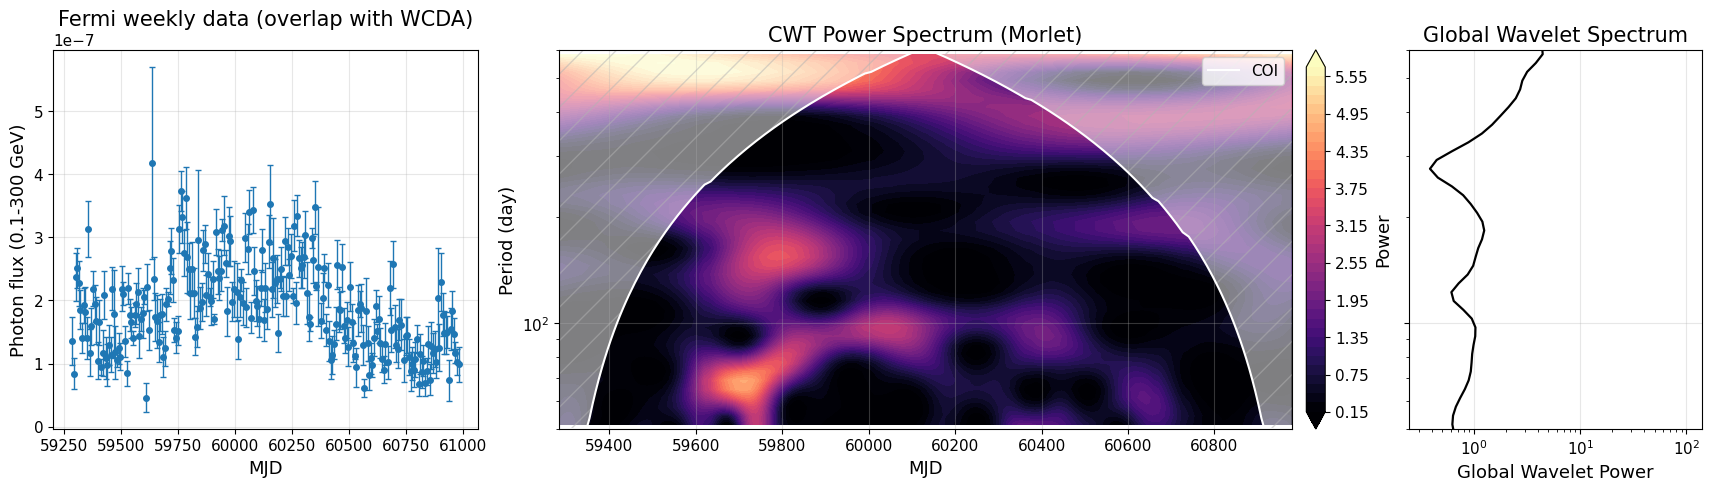

,period_day,power
0,873.656773,8.315435
1,583.095940,4.426257
2,183.663712,1.245982
3,97.292462,1.030201
4,40.906441,0.757103


In [6]:

fermi_cwt = run_cwt(t_fermi, flux_fermi, period_min=50.0, period_max=600.0)
fig, axes = plot_cwt_summary(
    t_fermi,
    flux_fermi,
    flux_err_fermi,
    fermi_cwt,
    lc_title='Fermi weekly data (overlap with WCDA)',
    flux_label='Photon flux (0.1-300 GeV)',
)
plt.show()

# 这里列出的只是“候选周期峰”，不是显著性结论。
fermi_cwt_candidates = top_period_candidates(fermi_cwt['period'], fermi_cwt['gws'], topk=5)
fermi_cwt_candidates


## 6. WWZ 分析

WWZ 对不规则采样更稳健，这里用来和 CWT 做互证。

*** Starting Weighted Wavelet Z-transform ***

adjusted time_divisions to:  238
Pseudo sample frequency (median) is  0.143
largest tau window is  7.148
10.51 seconds has passed to complete Weighted Wavelet Z-transform 



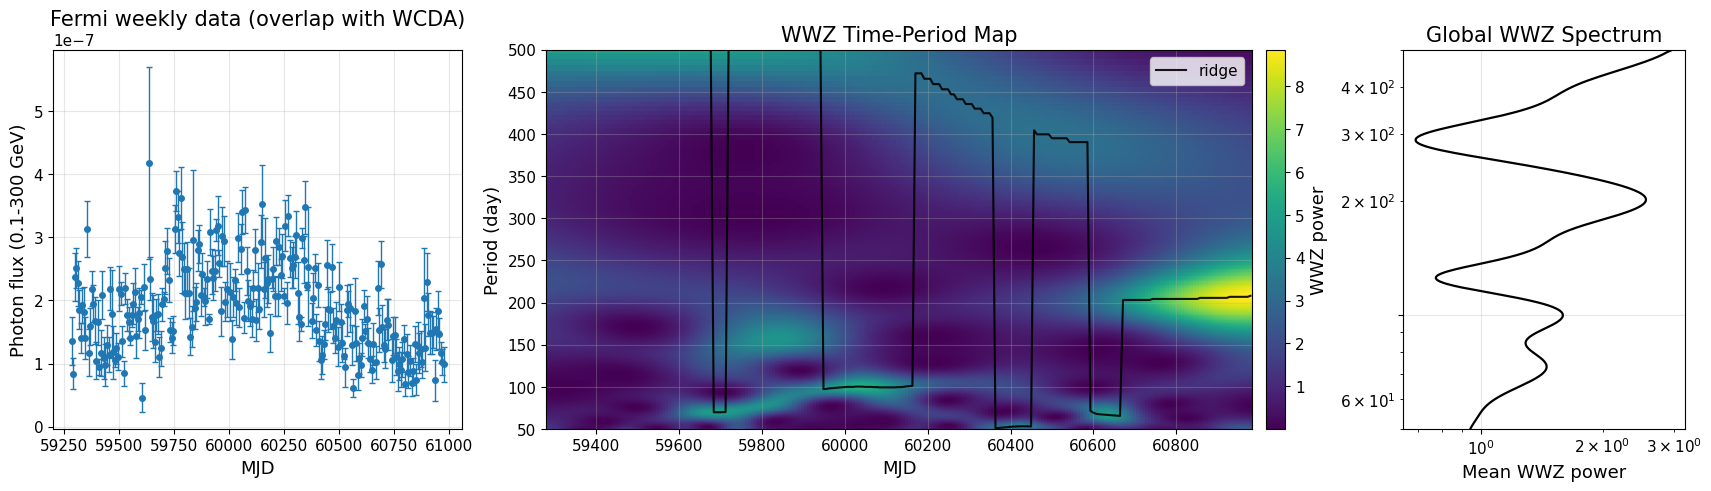

,period_day,power
0,200.758474,2.561329
1,99.717448,1.595778
2,73.055028,1.454881


In [7]:

fermi_wwz = run_wwz(
    t_fermi,
    flux_fermi,
    flux_err_fermi,
    period_min=50.0,
    period_max=500.0,
    time_divisions=250,
    decay_constant=0.0125,
)
fig, axes = plot_wwz_summary(
    fermi_wwz,
    lc_title='Fermi weekly data (overlap with WCDA)',
    flux_label='Photon flux (0.1-300 GeV)',
)
plt.show()

# 这里列出的只是“候选周期峰”，不是显著性结论。
fermi_wwz_candidates = top_period_candidates(fermi_wwz['period_axis'], fermi_wwz['global_wwz'], topk=5)
fermi_wwz_candidates


## 7. 简要结果说明

- 在与 WCDA 共同时段的 Fermi weekly 数据中，CWT / GWS 对约 **180 d** 和 **100 d** 左右的尺度给出了较明显的增强；同时还存在 **>500 d** 的长尺度结构，但这类特征同样接近有限基线长度，需要结合 COI 谨慎看待。
- Fermi 的 WWZ 时间平均谱给出的主要候选尺度集中在约 **200 d**、**100 d** 和 **70 d** 左右，可作为与 WCDA 候选尺度逐一比较的参照。
- 从目前的真实数据展示看，Fermi 与 WCDA 都出现了百天量级的增强结构，但是否对应同一物理周期仍需要后续显著性标定和联合分析来判断。
- 当前 notebook **未进行模拟、显著性阈值、pre-trial / post-trial、Monte Carlo 或 Emmanoulopoulos 检验**，因此这里不能把上述结构表述为显著周期检测结论。